# **YOUTUBE COMMENT SPAM DETECTION**

### **Importing All the Necessay Libraries/Modules/Packages**

In [35]:
import numpy as np
import pandas as pd
import sklearn
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import re

# Download NLTK Resources
nltk.download('punkt')
nltk.download('punkt_tabs')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Soro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Error loading punkt_tabs: Package 'punkt_tabs' not found
[nltk_data]     in index
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Soro\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Soro\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Soro\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## **1. Data Understanding**

### **1.1 Loading the Data**

In [36]:
data = pd.read_csv('Youtube-Spam-Dataset.csv')
data.head()

,COMMENT_ID,AUTHOR,DATE,CONTENT,VIDEO_NAME,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",PSY - GANGNAM STYLE(?????) M/V,1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,PSY - GANGNAM STYLE(?????) M/V,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,PSY - GANGNAM STYLE(?????) M/V,1
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,PSY - GANGNAM STYLE(?????) M/V,1
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,PSY - GANGNAM STYLE(?????) M/V,1


**Observations:**

- Here we can see, our dataset has 6 columns `COMMENT_ID`, `AUTHOR`, `DATE`, `CONTENT`, `VIDEO_NAME`, `CLASS`
- `COMMENT_ID`: Contains unique ids for each comments
- `AUTHOR` : Contains the User's Name who commented on the video
- `Date` : Contains all Date Info
- `CONTENT` : Contains the actual comment made by the user
- `VIDEO_NAME` : Contains the video name
- `CLASS` : Contains `0` or `1`, Here 0 means its not a spam and 1 means its a spam

Also About the Dataset Structure:
- we have 1956 rows 
- 6 columns

In [37]:
data.shape

(1956, 6)

In [38]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1956 entries, 0 to 1955
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   COMMENT_ID  1956 non-null   str  
 1   AUTHOR      1956 non-null   str  
 2   DATE        1711 non-null   str  
 3   CONTENT     1956 non-null   str  
 4   VIDEO_NAME  1956 non-null   str  
 5   CLASS       1956 non-null   int64
dtypes: int64(1), str(5)
memory usage: 91.8 KB


### **1.2 Handling Missing Values**

In [39]:
data.isna().sum()

COMMENT_ID      0
AUTHOR          0
DATE          245
CONTENT         0
VIDEO_NAME      0
CLASS           0
dtype: int64

**Observations:**

- We can see, `DATE` column has 245 missing Values 
- But for Our Model we dont need DATE column so, we will drop this column

In [40]:
data.drop(columns=['DATE','COMMENT_ID','VIDEO_NAME'],inplace=True)

In [41]:
data

,AUTHOR,CONTENT,CLASS
0,Julius NM,"Huh, anyway check out this you[tube] channel: ...",1
1,adam riyati,Hey guys check out my new channel and our firs...,1
2,Evgeny Murashkin,just for test I have to say murdev.com,1
3,ElNino Melendez,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1
4,GsMega,watch?v=vtaRGgvGtWQ Check this out .﻿,1
...,...,...,...
1951,Katie Mettam,I love this song because we sing it at Camp al...,0
1952,Sabina Pearson-Smith,I love this song for two reasons: 1.it is abou...,0
1953,jeffrey jules,wow,0
1954,Aishlin Maciel,Shakira u are so wiredo,0


### **1.3 Handling Duplicate Values**

In [42]:
data[data.duplicated()].count()

AUTHOR     55
CONTENT    55
CLASS      55
dtype: int64

In [43]:
data.drop_duplicates(inplace=True)

## **2. Exploratory Data Analysis (EDA)**

### **2.1 `CLASS` column Distribution Analysis**

In [44]:
class_count = data.CLASS.value_counts()
class_count.index = ['Spam','Not Spam']
class_count

Spam        958
Not Spam    943
Name: count, dtype: int64

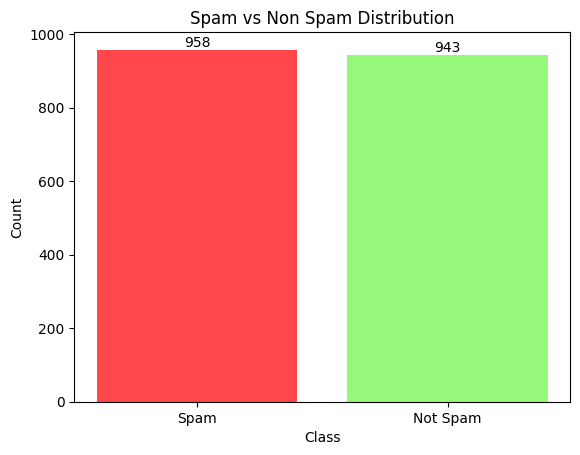

In [45]:
plt.title("Spam vs Non Spam Distribution")
bar = plt.bar(class_count.index,class_count,color=['xkcd:light red','xkcd:light green'])
plt.bar_label(bar)
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


**Observations:**

- The dataset is nearly perfectly balanced, containing 958 spam comments and 943 Non spam comments
- The number of spam comments (958) is slightly higher thab the number of non spam comments , the different is very minimal
- We don't need to worry about the data imbalance

### **2.2 Checking the Length of every Comments**

In [46]:
data['comment_length'] = data['CONTENT'].apply(lambda x: len(x.split()))

In [47]:
data.head()

,AUTHOR,CONTENT,CLASS,comment_length
0,Julius NM,"Huh, anyway check out this you[tube] channel: ...",1,8
1,adam riyati,Hey guys check out my new channel and our firs...,1,30
2,Evgeny Murashkin,just for test I have to say murdev.com,1,8
3,ElNino Melendez,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1,11
4,GsMega,watch?v=vtaRGgvGtWQ Check this out .﻿,1,5


In [48]:
data.groupby('CLASS')['comment_length'].mean()

CLASS
0     9.150583
1    20.697286
Name: comment_length, dtype: float64

**Observations:**

- The average word length for spam comments are ~9 words 
- The average word length for non spam comments are ~ 20 words 
- This shows that Spam comments are generally small in size compared to legit comments

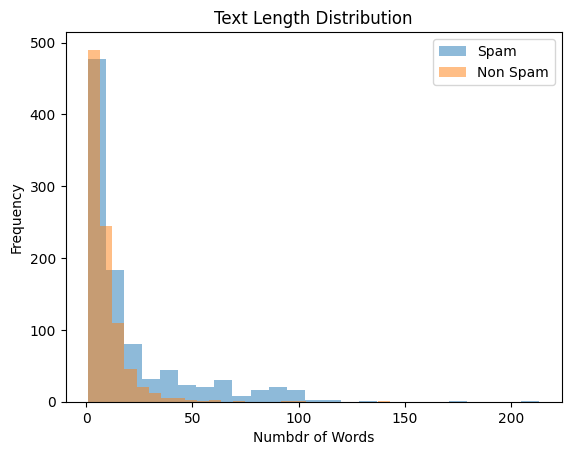

In [49]:
# For Spam
spam_com_length = comment_length = data[data['CLASS'] == 1]['comment_length']

# For Non Spam
Nonspam_com_length = comment_length = data[data['CLASS'] == 0]['comment_length']

plt.title("Text Length Distribution")
plt.hist(spam_com_length,bins=25,alpha=0.5,label='Spam')
plt.hist(Nonspam_com_length,bins=25,alpha=0.5,label='Non Spam')
plt.xlabel('Numbdr of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**Observations:**

- Most Comments are short 
- Spam comments are more spread out
- Non spam comments are more concentrated

## **3. Text Preprocessing**

### **3.1 Cleaning the `CONTENT` columns data**

- Here we will create a function called `cleaning_text()` , which will take a text as a parameter
- We will apply this function to our `CONTENT` column using a pandas method called `apply()` 

In [50]:
data['CONTENT'].head()

0    Huh, anyway check out this you[tube] channel: ...
1    Hey guys check out my new channel and our firs...
2               just for test I have to say murdev.com
3     me shaking my sexy ass on my channel enjoy ^_^ ﻿
4              watch?v=vtaRGgvGtWQ   Check this out .﻿
Name: CONTENT, dtype: str

In [51]:
stop_words = set(stopwords.words('english'))
lemmetizer = WordNetLemmatizer()

def cleaning_text(text):
    
    # Converting our text into lower case
    text = text.lower()

    # Removing Special Characters
    text = re.sub(r"[^a-zA-z\s]",'',text)

    # Tokenization
    words = text.split()

    # Stopwords Removal
    words = [word for word in words if word not in stop_words]

    # Lemmetization
    cleaned_words = [lemmetizer.lemmatize(word) for word in words]

    return " ".join(cleaned_words)

In [52]:
data["CLEANED_CONTENT"] = data['CONTENT'].apply(cleaning_text)

In [53]:
data.head()

,AUTHOR,CONTENT,CLASS,comment_length,CLEANED_CONTENT
0,Julius NM,"Huh, anyway check out this you[tube] channel: ...",1,8,huh anyway check you[tube] channel kobyoshi
1,adam riyati,Hey guys check out my new channel and our firs...,1,30,hey guy check new channel first vid u monkey i...
2,Evgeny Murashkin,just for test I have to say murdev.com,1,8,test say murdevcom
3,ElNino Melendez,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1,11,shaking sexy as channel enjoy ^_^
4,GsMega,watch?v=vtaRGgvGtWQ Check this out .﻿,1,5,watchvvtarggvgtwq check


**Conclusion:**

- We have cleaned our `CONTENT` column and created a new one named `CLEANED_CONTENT`
- First we made our content in one case that is lower case
- We removed all the special characters and stopwords because we don't need those for model training
- We performed Lemmetization to preserve the word meaning and remove the sufix and prefix if needed.

Now, We are good to go to use this column for Model Building

## **4. Model Building**

### **4.1 Dividing the data into X (input Features) and y (output)**

In [54]:
X = data['CLEANED_CONTENT']
y = data['CLASS']

### **4.2 Splitting X and y into Train and Test**

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.75,random_state=42)

### **4.3 Passing `X_train` into TF-IDF vectorizer for transformation**

- Right Now , our `X_train` is in text format , but to train the model we need numerical Values
- To achieve the numerical Values , we need to pass our Dataframe into a Vectorizer 
- For this project, We are select TF-IDF to convert our data 

In [56]:
tf_idf_vec = TfidfVectorizer()

X_train_transf = tf_idf_vec.fit_transform(X_train)

### **4.4 Training the MultinomialNB Model**

- As of now, we only know about MultinomialNB algorithm, thats why we are using this to train our Model

In [57]:
from sklearn.naive_bayes import MultinomialNB

MultiNom_model = MultinomialNB()
MultiNom_model.fit(X_train_transf,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### **4.5 Passing `X_test` into TF-IDF vectorizer for transformation**

In [58]:
X_test_transf = tf_idf_vec.transform(X_test)

### **4.6 Generating the y-pred**

- Here, we will try to generate some prediction by passing the X_test data
- Later, we compare with y_test to get the accuracy

In [59]:
y_pred = MultiNom_model.predict(X_test_transf)

### **4.7 Evaluating by using accuracy score**

In [60]:
score = accuracy_score(y_test,y_pred)
print("Accuracy Score:",score)

Accuracy Score: 0.8907563025210085


## **Exporting our Model**

In [61]:
import joblib

joblib.dump({
    'model': MultiNom_model,
    'vectorizer': tf_idf_vec
}, 'yt_spam_detection_model')

['yt_spam_detection_model']